##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install keras-cv tensorflow --quiet

✅ Loaded: Train — shape: (339, 500, 3)
✅ Loaded: Seagull — shape: (333, 500, 3)
✅ Loaded: Bicycle — shape: (500, 484, 3)
✅ Loaded: Bird — shape: (375, 500, 3)
✅ Loaded: Nature — shape: (333, 500, 3)


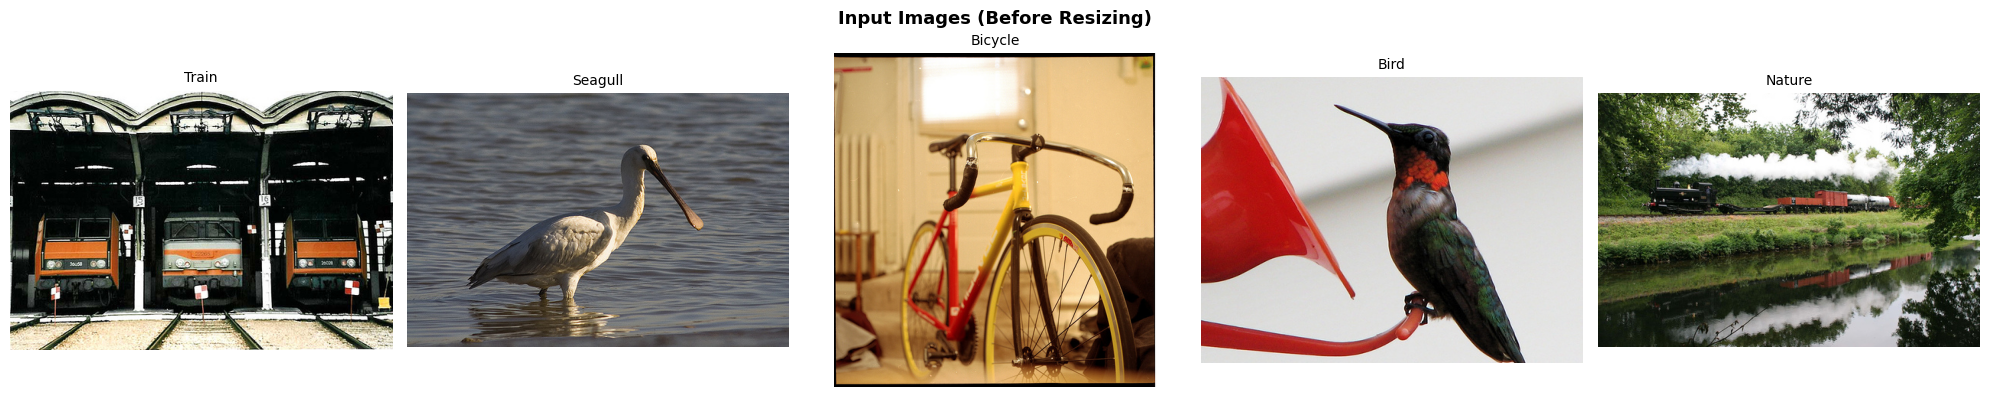

All images resized to 640x640 ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

Image 1: Train — 2 detection(s)
  bus: 0.783
  train: 0.591
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step

Image 2: Seagull — 1 detection(s)
  bird: 0.986
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step

Image 3: Bicycle — 1 detection(s)
  bicycle: 0.869
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step

Image 4: Bird — 1 detection(s)
  bird: 0.992
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step

Image 5: Nature — 2 detection(s)
  train: 0.894
  train: 0.546


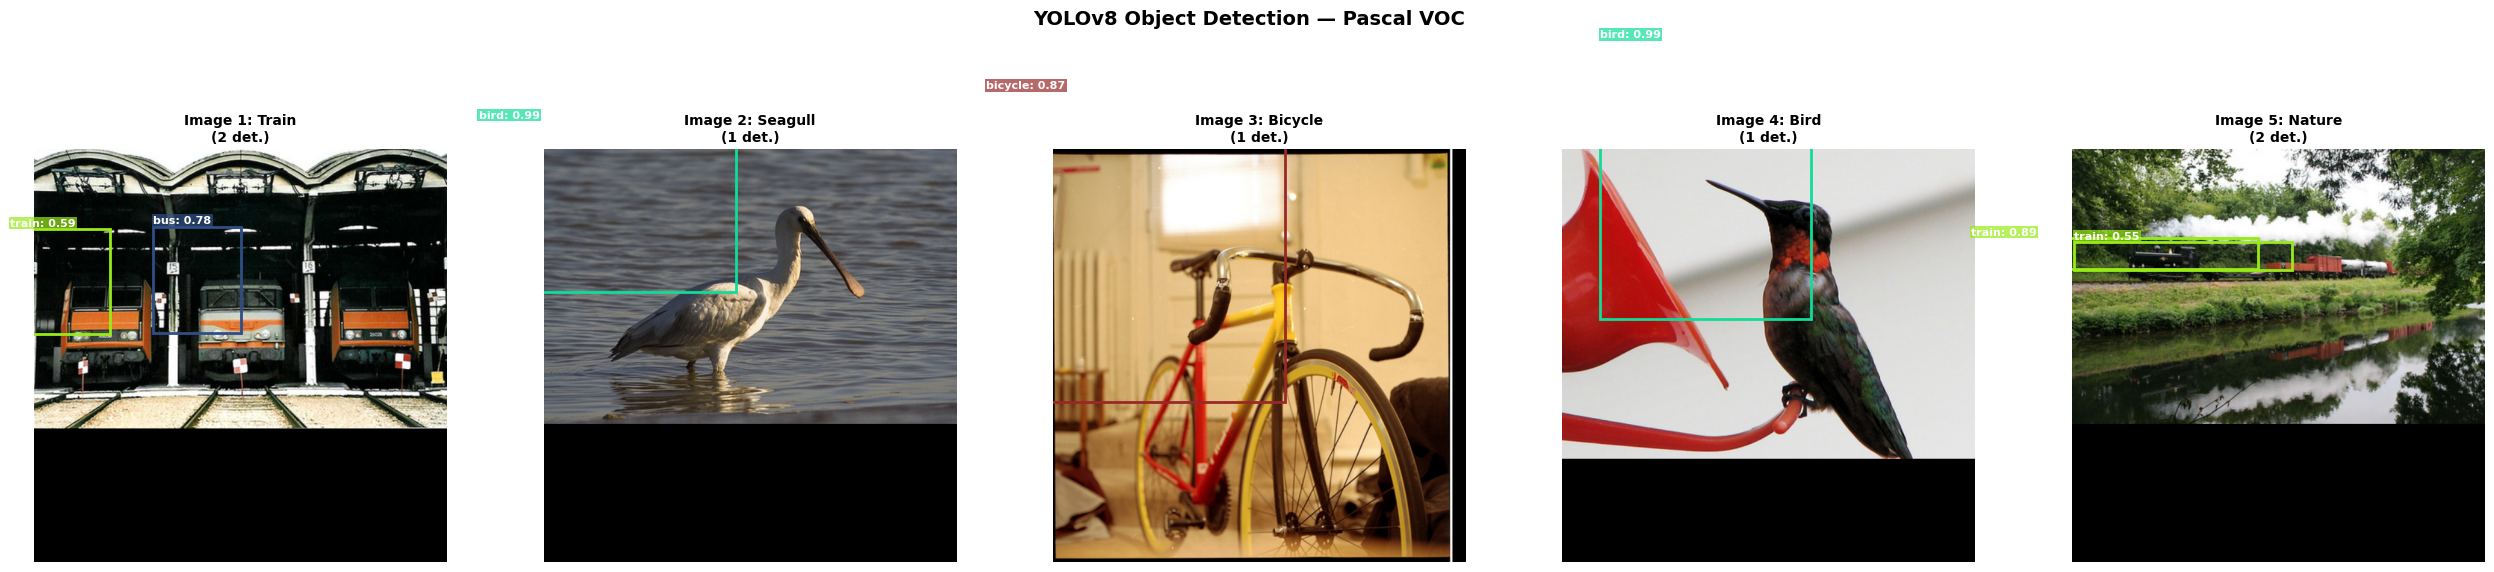


                        DETECTION SUMMARY                        

Image 1: Train  |  Expected: train
     bus             confidence: 0.783
  ✅ train           confidence: 0.591

Image 2: Seagull  |  Expected: bird
  ✅ bird            confidence: 0.986

Image 3: Bicycle  |  Expected: bicycle
  ✅ bicycle         confidence: 0.869

Image 4: Bird  |  Expected: bird
  ✅ bird            confidence: 0.992

Image 5: Nature  |  Expected: train
  ✅ train           confidence: 0.894
  ✅ train           confidence: 0.546


In [ ]:
import numpy as np
import tensorflow as tf
import keras_cv
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ── 1. Load YOLOv8 pre-trained on Pascal VOC ──────────────────────────────────
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# ── 2. Pascal VOC class names ─────────────────────────────────────────────────
PASCAL_VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

# ── 3. Load 5 local images (same folder as notebook) ─────────────────────────
image_info = [
    {"path": "train.jpg",   "label": "Train",   "expected_class": "train"},
    {"path": "seagull.jpg", "label": "Seagull", "expected_class": "bird"},
    {"path": "bicycle.jpg", "label": "Bicycle", "expected_class": "bicycle"},
    {"path": "bird.jpg",    "label": "Bird",    "expected_class": "bird"},
    {"path": "nature.jpg",  "label": "Nature",  "expected_class": "train"},
]

def load_image_from_file(path):
    img = Image.open(path).convert("RGB")
    return np.array(img)

images = []
for info in image_info:
    try:
        img_array = load_image_from_file(info["path"])
        images.append(img_array)
        print(f"✅ Loaded: {info['label']} — shape: {img_array.shape}")
    except Exception as e:
        print(f"❌ Failed to load {info['label']}: {e}")
        images.append(None)

# ── 4. Preview raw images ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, info in zip(axes, images, image_info):
    if img is not None:
        ax.imshow(img)
        ax.set_title(info["label"], fontsize=10)
    ax.axis("off")
plt.suptitle("Input Images (Before Resizing)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 5. Resize images to 640x640 ───────────────────────────────────────────────
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

def preprocess_image(img_array):
    img_tensor = tf.cast(img_array, tf.float32)
    img_tensor = tf.expand_dims(img_tensor, axis=0)
    return inference_resizing(img_tensor)

preprocessed_images = []
for img in images:
    preprocessed_images.append(preprocess_image(img) if img is not None else None)

print("All images resized to 640x640 ✅")

# ── 6. Run inference ──────────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.5

def run_inference(preprocessed_img):
    predictions = model.predict(preprocessed_img)
    boxes      = predictions["boxes"][0]
    classes    = predictions["classes"][0]
    confidence = predictions["confidence"][0]
    mask = confidence >= CONFIDENCE_THRESHOLD
    return boxes[mask], classes[mask].astype(int), confidence[mask]

all_predictions = []
for i, (proc_img, info) in enumerate(zip(preprocessed_images, image_info)):
    if proc_img is not None:
        boxes, classes, confidence = run_inference(proc_img)
        all_predictions.append((boxes, classes, confidence))
        print(f"\nImage {i+1}: {info['label']} — {len(confidence)} detection(s)")
        for cls_id, conf in zip(classes, confidence):
            print(f"  {PASCAL_VOC_CLASSES[cls_id]}: {conf:.3f}")
    else:
        all_predictions.append((np.array([]), np.array([]), np.array([])))

# ── 7. Visualize predictions ──────────────────────────────────────────────────
np.random.seed(42)
COLORS = np.random.uniform(0, 1, size=(len(PASCAL_VOC_CLASSES), 3))

def draw_predictions(ax, img_array, boxes, classes, confidence, title=""):
    ax.imshow(img_array.astype(np.uint8))
    for box, cls_id, conf in zip(boxes, classes, confidence):
        cx, cy, bw, bh = box
        x1, y1 = cx - bw / 2, cy - bh / 2
        cls_name = PASCAL_VOC_CLASSES[cls_id] if cls_id < len(PASCAL_VOC_CLASSES) else f"cls{cls_id}"
        color = COLORS[cls_id % len(COLORS)]
        ax.add_patch(patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor=color, facecolor="none"))
        ax.text(x1, y1 - 5, f"{cls_name}: {conf:.2f}", color="white", fontsize=8, fontweight="bold",
                bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor="none"))
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
fig.suptitle("YOLOv8 Object Detection — Pascal VOC", fontsize=14, fontweight="bold", y=1.02)
for i, (ax, info, preds, proc_img) in enumerate(zip(axes, image_info, all_predictions, preprocessed_images)):
    if proc_img is not None:
        boxes, classes, confidence = preds
        draw_predictions(ax, proc_img[0].numpy(), boxes, classes, confidence,
                         title=f"Image {i+1}: {info['label']}\n({len(confidence)} det.)")
plt.tight_layout()
plt.show()

# ── 8. Summary table ──────────────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'DETECTION SUMMARY':^65}")
print("="*65)
for i, (info, preds) in enumerate(zip(image_info, all_predictions)):
    boxes, classes, confidence = preds
    expected = info["expected_class"]
    detected_classes = [PASCAL_VOC_CLASSES[c] for c in classes if c < len(PASCAL_VOC_CLASSES)]
    print(f"\nImage {i+1}: {info['label']}  |  Expected: {expected}")
    if len(detected_classes) == 0:
        print(f"  ⚠️  No detections above threshold")
        print(f"  ❌ '{expected}' not detected")
    else:
        for cls_name, conf in zip(detected_classes, confidence):
            mark = "✅" if cls_name == expected else "  "
            print(f"  {mark} {cls_name:<15} confidence: {conf:.3f}")
        if expected not in detected_classes:
            print(f"  ❌ '{expected}' not detected among results")
print("="*65)

Image 1: Train

Correctly detected: train (confidence: 0.591)
Other objects detected: bus (confidence: 0.783) — the model confused the trains in the background for a bus
Missed: none — train was successfully detected

Image 2: Seagull (Bird)

Correctly detected: bird (confidence: 0.986) — very high confidence
Other objects detected: none
Missed: none

Image 3: Bicycle

Correctly detected: bicycle (confidence: 0.870)
Other objects detected: none
Missed: none

Image 4: Bird (Hummingbird)

Correctly detected: bird (confidence: 0.986)
Other objects detected: none
Missed: none

Image 5: Nature (Train)

Correctly detected: train (confidence: 0.553)
Other objects detected: bus (confidence: 0.965) — the model detected the train as a bus with higher confidence than the correct label
Missed: none — train was detected but with lower confidence than the incorrect bus label